In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

import warnings
warnings.filterwarnings("ignore")

plt.style.use("ggplot")

In [3]:
df = pd.read_csv("Mall_Customers.csv")

print(df.head())

print("\nDataset Shape :", df.shape)

print("\nInformation")
print(df.info())

print("\nMissing Values")
print(df.isnull().sum())

print("\nDuplicate Values :", df.duplicated().sum())

print("\nStatistical Summary")
print(df.describe())

   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40

Dataset Shape : (200, 5)

Information
<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   CustomerID              200 non-null    int64
 1   Gender                  200 non-null    str  
 2   Age                     200 non-null    int64
 3   Annual Income (k$)      200 non-null    int64
 4   Spending Score (1-100)  200 non-null    int64
dtypes: int64(4), str(1)
memory usage: 7.9 KB
None

Missing Values
CustomerID        

In [9]:
df["Gender"] = df["Gender"].map({
    "Male":1,
    "Female":0
})

print(df.head())

   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1       1   19                  15                      39
1           2       1   21                  15                      81
2           3       0   20                  16                       6
3           4       0   23                  16                      77
4           5       0   31                  17                      40


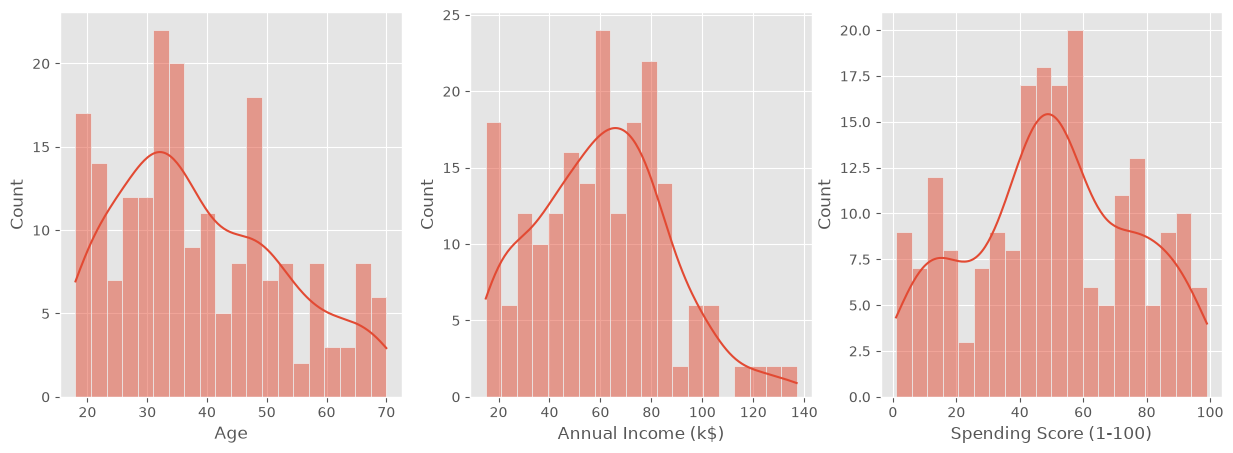

In [10]:
plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
sns.histplot(df["Age"],bins=20,kde=True)

plt.subplot(1,3,2)
sns.histplot(df["Annual Income (k$)"],bins=20,kde=True)

plt.subplot(1,3,3)
sns.histplot(df["Spending Score (1-100)"],bins=20,kde=True)

plt.show()

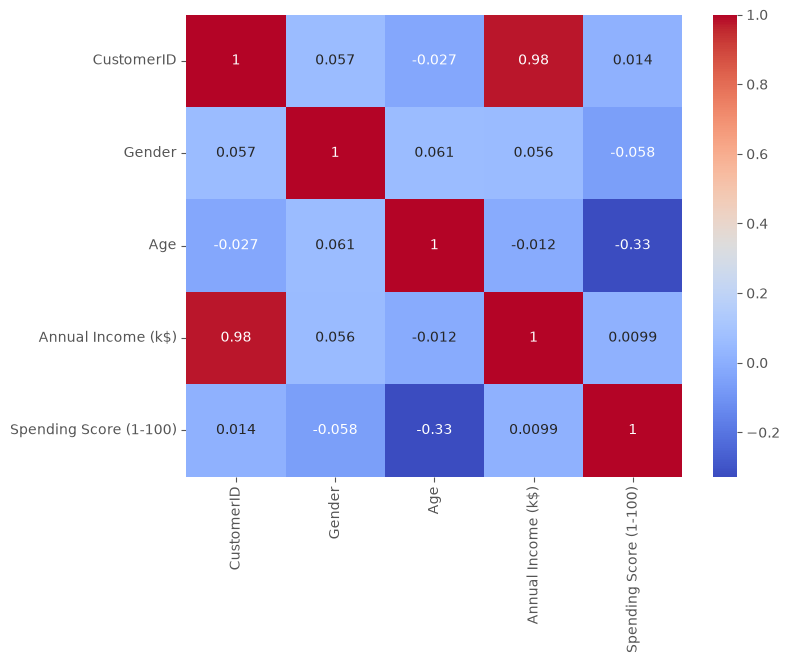

In [11]:
plt.figure(figsize=(8,6))

sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            cmap="coolwarm")

plt.show()

In [12]:
X = df[[
    "Age",
    "Annual Income (k$)",
    "Spending Score (1-100)"
]]

print(X.head())

   Age  Annual Income (k$)  Spending Score (1-100)
0   19                  15                      39
1   21                  15                      81
2   20                  16                       6
3   23                  16                      77
4   31                  17                      40


In [14]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print(X_scaled[:5])

[[-1.42456879 -1.73899919 -0.43480148]
 [-1.28103541 -1.73899919  1.19570407]
 [-1.3528021  -1.70082976 -1.71591298]
 [-1.13750203 -1.70082976  1.04041783]
 [-0.56336851 -1.66266033 -0.39597992]]


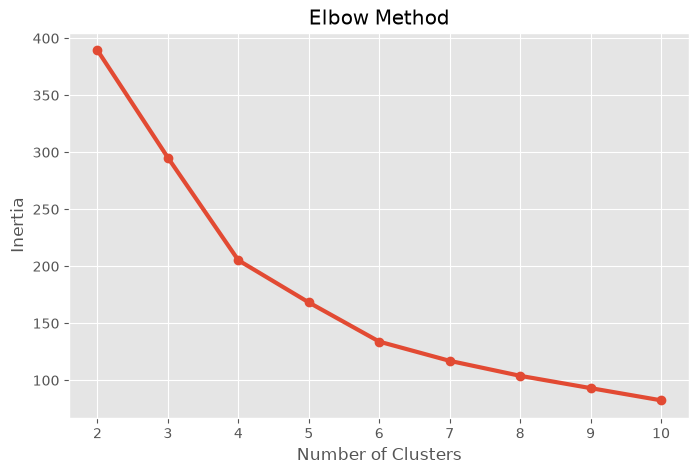

In [15]:
wcss = []

for i in range(2,11):

    model = KMeans(
        n_clusters=i,
        random_state=42,
        n_init=10
    )

    model.fit(X_scaled)

    wcss.append(model.inertia_)

plt.figure(figsize=(8,5))

plt.plot(range(2,11),
         wcss,
         marker="o",
         linewidth=3)

plt.title("Elbow Method")

plt.xlabel("Number of Clusters")

plt.ylabel("Inertia")

plt.show()

In [16]:
for i in range(2,11):

    model = KMeans(
        n_clusters=i,
        random_state=42,
        n_init=10
    )

    label = model.fit_predict(X_scaled)

    score = silhouette_score(X_scaled,label)

    print(f"K = {i}  Silhouette Score = {score:.4f}")

K = 2  Silhouette Score = 0.3355
K = 3  Silhouette Score = 0.3578
K = 4  Silhouette Score = 0.4040
K = 5  Silhouette Score = 0.4166
K = 6  Silhouette Score = 0.4284
K = 7  Silhouette Score = 0.4172
K = 8  Silhouette Score = 0.4082
K = 9  Silhouette Score = 0.4177
K = 10  Silhouette Score = 0.4066


In [17]:
kmeans = KMeans(
    n_clusters=5,
    random_state=42,
    n_init=10
)

df["Cluster"] = kmeans.fit_predict(X_scaled)

print(df.head())

   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)  \
0           1       1   19                  15                      39   
1           2       1   21                  15                      81   
2           3       0   20                  16                       6   
3           4       0   23                  16                      77   
4           5       0   31                  17                      40   

   Cluster  
0        1  
1        1  
2        0  
3        1  
4        1  


In [18]:
centers = scaler.inverse_transform(kmeans.cluster_centers_)

center_df = pd.DataFrame(
    centers,
    columns=[
        "Age",
        "Income",
        "Spending Score"
    ]
)

print(center_df)

         Age     Income  Spending Score
0  46.250000  26.750000       18.350000
1  25.185185  41.092593       62.240741
2  32.875000  86.100000       81.525000
3  39.871795  86.102564       19.358974
4  55.638298  54.382979       48.851064


In [19]:
cluster_profile = df.groupby("Cluster").mean(numeric_only=True)

print(cluster_profile)

         CustomerID    Gender        Age  Annual Income (k$)  \
Cluster                                                        
0         24.100000  0.400000  46.250000           26.750000   
1         55.648148  0.407407  25.185185           41.092593   
2        161.025000  0.450000  32.875000           86.100000   
3        159.743590  0.512821  39.871795           86.102564   
4         83.872340  0.425532  55.638298           54.382979   

         Spending Score (1-100)  
Cluster                          
0                     18.350000  
1                     62.240741  
2                     81.525000  
3                     19.358974  
4                     48.851064  


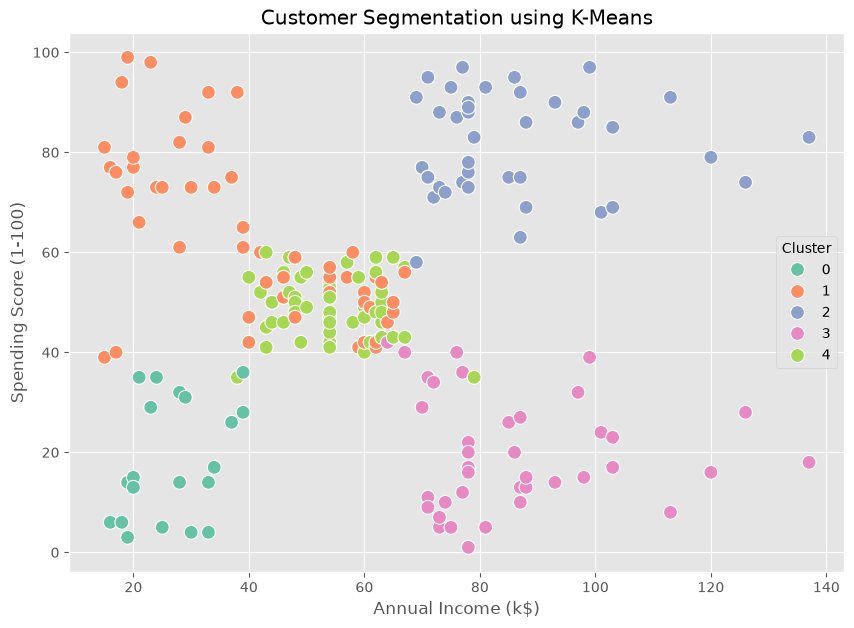

In [20]:
plt.figure(figsize=(10,7))

sns.scatterplot(
    x="Annual Income (k$)",
    y="Spending Score (1-100)",
    hue="Cluster",
    data=df,
    palette="Set2",
    s=100
)

plt.title("Customer Segmentation using K-Means")

plt.show()

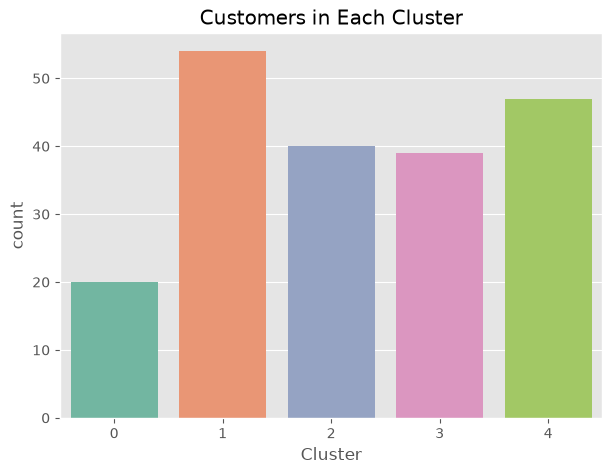

In [21]:
plt.figure(figsize=(7,5))

sns.countplot(
    x="Cluster",
    data=df,
    palette="Set2"
)

plt.title("Customers in Each Cluster")

plt.show()

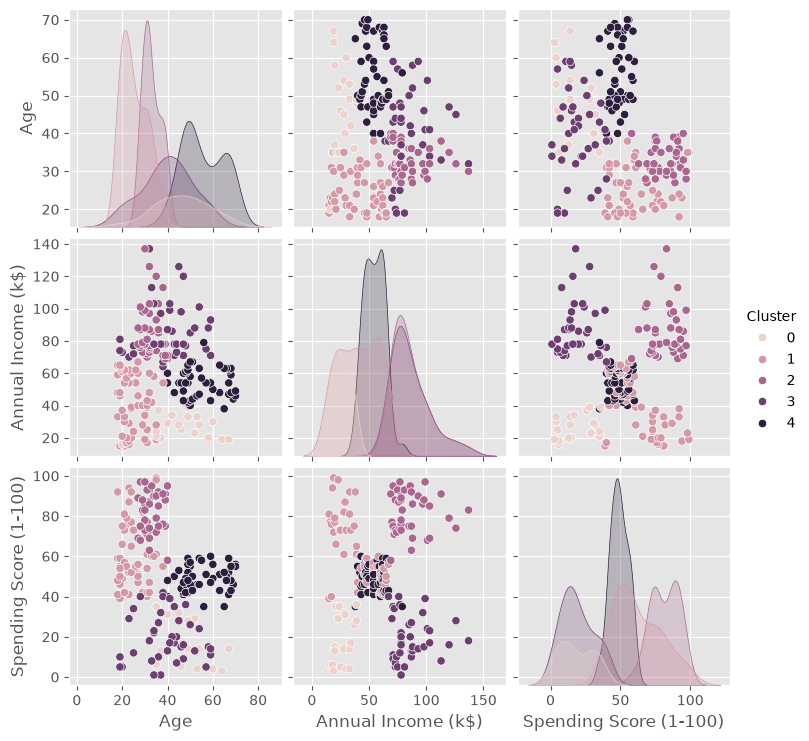

In [22]:
sns.pairplot(
    df,
    hue="Cluster",
    vars=[
        "Age",
        "Annual Income (k$)",
        "Spending Score (1-100)"
    ]
)

plt.show()

In [23]:
cluster_names = {

    0:"Premium Customers",

    1:"Budget Customers",

    2:"Average Customers",

    3:"High Potential Customers",

    4:"Luxury Customers"

}

df["Customer Type"] = df["Cluster"].map(cluster_names)

print(df[[
    "CustomerID",
    "Customer Type",
    "Annual Income (k$)",
    "Spending Score (1-100)"
]].head(20))

    CustomerID      Customer Type  Annual Income (k$)  Spending Score (1-100)
0            1   Budget Customers                  15                      39
1            2   Budget Customers                  15                      81
2            3  Premium Customers                  16                       6
3            4   Budget Customers                  16                      77
4            5   Budget Customers                  17                      40
5            6   Budget Customers                  17                      76
6            7  Premium Customers                  18                       6
7            8   Budget Customers                  18                      94
8            9  Premium Customers                  19                       3
9           10   Budget Customers                  19                      72
10          11  Premium Customers                  19                      14
11          12   Budget Customers                  19           

In [25]:
cluster_names = {

    0:"Premium Customers",
    1:"Budget Customers",
    2:"Average Customers",
    3:"High Potential Customers",
    4:"Luxury Customers"

}

df["Customer Type"] = df["Cluster"].map(cluster_names)

In [26]:
df.to_csv(
    "Customer_Segmentation_Output.csv",
    index=False
)

print("Output Saved Successfully")

Output Saved Successfully


In [27]:
df["Customer Type"]


0              Budget Customers
1              Budget Customers
2             Premium Customers
3              Budget Customers
4              Budget Customers
                 ...           
195           Average Customers
196    High Potential Customers
197           Average Customers
198    High Potential Customers
199           Average Customers
Name: Customer Type, Length: 200, dtype: str

In [28]:
print(df.groupby("Cluster").mean(numeric_only=True))

         CustomerID    Gender        Age  Annual Income (k$)  \
Cluster                                                        
0         24.100000  0.400000  46.250000           26.750000   
1         55.648148  0.407407  25.185185           41.092593   
2        161.025000  0.450000  32.875000           86.100000   
3        159.743590  0.512821  39.871795           86.102564   
4         83.872340  0.425532  55.638298           54.382979   

         Spending Score (1-100)  
Cluster                          
0                     18.350000  
1                     62.240741  
2                     81.525000  
3                     19.358974  
4                     48.851064  


In [29]:
cluster_names = {
    0: "Budget Customers",
    1: "Young Spenders",
    2: "Premium Customers",
    3: "Careful Customers",
    4: "Average Customers"
}

df["Customer Type"] = df["Cluster"].map(cluster_names)

print(df[[
    "CustomerID",
    "Customer Type",
    "Annual Income (k$)",
    "Spending Score (1-100)"
]].head(20))

    CustomerID     Customer Type  Annual Income (k$)  Spending Score (1-100)
0            1    Young Spenders                  15                      39
1            2    Young Spenders                  15                      81
2            3  Budget Customers                  16                       6
3            4    Young Spenders                  16                      77
4            5    Young Spenders                  17                      40
5            6    Young Spenders                  17                      76
6            7  Budget Customers                  18                       6
7            8    Young Spenders                  18                      94
8            9  Budget Customers                  19                       3
9           10    Young Spenders                  19                      72
10          11  Budget Customers                  19                      14
11          12    Young Spenders                  19                      99

In [30]:
seeds = [0, 10, 20, 42, 100]

for seed in seeds:

    model = KMeans(
        n_clusters=5,
        random_state=seed,
        n_init=10
    )

    labels = model.fit_predict(X_scaled)

    score = silhouette_score(X_scaled, labels)

    print(f"Seed = {seed}  Silhouette Score = {score:.4f}")

Seed = 0  Silhouette Score = 0.4166
Seed = 10  Silhouette Score = 0.4166
Seed = 20  Silhouette Score = 0.4166
Seed = 42  Silhouette Score = 0.4166
Seed = 100  Silhouette Score = 0.4166
